# Terwilliger Algebra of Distance-Regular Graphs

This notebook implements the computation of the Terwilliger algebra \(T(x)\) of a distance-regular graph and performs its module-theoretic analysis. The motivation for this notebook comes from the following work: (https://arxiv.org/pdf/2606.05393)

## Notes

- During development, several exploratory functions and test cells were created. Some of these are retained for reference but are **not** part of the final analysis pipeline.
-  If you want to take a quick glance in the final irreducible module decomposition, please consult the **print_summary()** section at the end of the notebook.
- The main functions used in the final workflow are `analyze_isotypic_component()`, `terwilliger_module_analysis()`, and `print_summary()`.
- Final results are stored at `results` and `print_summary`, both of which are the last two cells of this notebook.
- The notebook is still a 'work in progress' for further analysis, for example - I haven't produced the seed vectors yet.

In [84]:
from sage.graphs.graph_generators import graphs

#Gr = graphs.Klein7RegularGraph()
#Gr = graphs.PetersenGraph()
#Gr = graphs.FosterGraph()
#Gr = graphs.PappusGraph()
#Gr = graphs.HeawoodGraph()
#Gr = graphs.DesarguesGraph()
Gr = graphs.TutteCoxeterGraph()
#Gr = graphs.PaleyGraph(9)
print(Gr)

Tutte-Coxeter graph


In [85]:
array = Gr.is_distance_regular(parameters=True)
print(array)

([3, 2, 2, 2, None], [None, 1, 1, 1, 3])


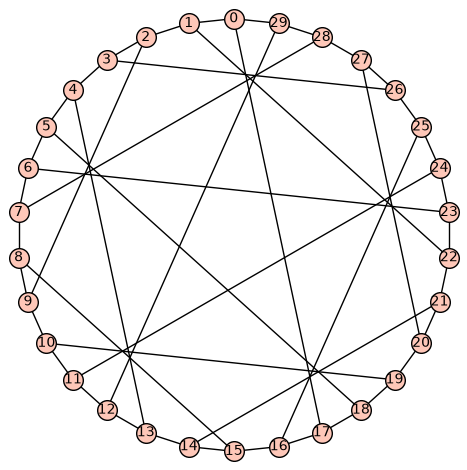

In [86]:
x0 = 0                          
Gr.plot()

## Distance Matrix and Basic Parameters

Compute the distance matrix of the graph and determine its diameter. These quantities are used throughout the construction of the Terwilliger algebra.

**Variables**
- `Dmat` – the distance matrix of the graph.
- `d_diam` – the diameter of the graph.
- `nc` – the number of distance classes, equal to `d_diam + 1`.
- `N` – the number of vertices of the graph.

In [87]:
Dmat = Gr.distance_matrix()
d_diam = max(max(row) for row in Dmat)
nc = d_diam + 1                

print(f"{Gr} has {Gr.num_verts()} vertices, diameter {d_diam}")
N = Gr.num_verts()

Tutte-Coxeter graph has 30 vertices, diameter 4


## Distance Matrices and Dual Idempotents

Construct the distance matrices and the dual idempotents with respect to the chosen base vertex. These matrices generate the Terwilliger algebra.

**Variables**
- `Amats` – list of distance matrices $[A_0, A_1, \ldots, A_d]$, where `Amats[i]` records pairs of vertices at distance `i`.
- `Estar` – list of dual idempotents $[E_0^*, E_1^*, \ldots, E_d^*]$ corresponding to the distance partition from the base vertex `x0`.

In [88]:
Amats = [matrix(QQ, N, N) for _ in range(nc)]
for x in range(N):
    for y in range(N):
        Amats[Dmat[x, y]][x, y] = 1

Estar = []
for i in range(nc):
    diag = [1 if Dmat[x0, y] == i else 0 for y in range(N)]
    Estar.append(diagonal_matrix(QQ, diag))
Amats

[30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field]

## Verify Distance-Regularity

Compute the valency sequence and verify that the graph is regular and distance-regular by checking that the intersection numbers $(c_i, a_i, b_i)$ are constant for every distance layer.

**Variables**
- valency: the sequence of valencies $k_i$, where $k_i$ is the number of vertices at distance $i$ from the base vertex.
- k: the valency of the graph.

In [89]:
valency = [Amats[i].row(x0).list().count(1) for i in range(nc)]
print("valency sequence k_i:", valency)
print("sum k_i == N:", sum(valency) == N)


k = valency[1]
assert all(Amats[1].row(v).list().count(1) == k for v in range(N)), "not even regular!"


def check_distance_regularity(Amats, Dmat, nc):
    for i in range(nc):
        verts_at_i = [y for y in range(N) if Dmat[x0, y] == i]
        for y in verts_at_i:
            c = sum(1 for z in range(N) if Amats[1][y, z] == 1 and Dmat[x0, z] == i - 1)
            a = sum(1 for z in range(N) if Amats[1][y, z] == 1 and Dmat[x0, z] == i)
            b = sum(1 for z in range(N) if Amats[1][y, z] == 1 and Dmat[x0, z] == i + 1)
            yield (i, y, c, a, b)

intersection_data = list(check_distance_regularity(Amats, Dmat, nc))
by_dist = {}

for i, y, c, a, b in intersection_data:
    by_dist.setdefault(i, set()).add((c, a, b))
    
print("constant (c_i,a_i,b_i) per distance?", all(len(v) == 1 for v in by_dist.values()))

for i in sorted(by_dist):
    print(f"  distance {i}: (c,a,b) = {list(by_dist[i])[0]}")

valency sequence k_i: [1, 3, 6, 12, 8]
sum k_i == N: True
constant (c_i,a_i,b_i) per distance? True
  distance 0: (c,a,b) = (0, 0, 3)
  distance 1: (c,a,b) = (1, 0, 2)
  distance 2: (c,a,b) = (1, 0, 2)
  distance 3: (c,a,b) = (1, 0, 2)
  distance 4: (c,a,b) = (3, 0, 0)


## Generators of the Terwilliger Algebra

Define the generators of the Terwilliger algebra and a helper function for computing the commutator Gram matrix. This matrix is used to determine the centralizer (center) of the algebra.

**Variables**
- `gens` – the generators of the Terwilliger algebra, consisting of the distance matrices and the dual idempotents.

In [7]:
gens = Amats + Estar

def commutator_gram(basis, gens):
    """

    INPUT:
        basis : basis of the matrix algebra
        gens  : generators of the Terwilliger algebra

    OUTPUT:
        Gram matrix whose kernel consists of matrices commuting with every
        generator of T.
    """

    rows = []

    for Bmat in basis:

        row = []

        for g in gens:

            comm = Bmat * g - g * Bmat

            row += comm.list()

        rows.append(row)

    comm_matrix = matrix(QQ, rows)

    return comm_matrix * comm_matrix.transpose()

## Construct a Basis for the Terwilliger Algebra

Construct a basis for the Terwilliger algebra by generating products of the form

$[
E_i^* A E_j^* A \cdots E_k^*,
]$

using the adjacency matrix and the dual idempotents. The construction exploits the distance-regular property by considering only adjacent distance layers, since all other products are zero.

**Function**
- `terwilliger_basis_DRG` – constructs a basis of the Terwilliger algebra associated with the chosen base vertex.

In [8]:
def terwilliger_basis_DRG(Amats, Estar, gen_index=1, max_depth=None):
    """Like terwilliger_basis, but only uses A_{gen_index} (default A_1) as the
    matrix generator, and only tries E_i* A E_j* combinations with |i-j|<=1 —
    everything else is zero by distance-regularity, so we never even build it."""
    nc = len(Estar)
    A = Amats[gen_index]
    max_depth = max_depth or nc   # how many factors of A to try before stopping
    max_depth = max_depth

    basis, piv_cols, red_rows = [], [], []
    def reduce_vec(v):
        for piv, row in zip(piv_cols, red_rows):
            if v[piv] != 0:
                f = v[piv]
                v = [a - f*b for a, b in zip(v, row)]
        return v

    def try_add(M):
        if M.is_zero():
            return False
        v = reduce_vec(M.list())
        piv = next((idx for idx, val in enumerate(v) if val != 0), None)
        if piv is None:
            return False
        v = [a / v[piv] for a in v]
        for t in range(len(red_rows)):
            c = red_rows[t][piv]
            if c != 0:
                red_rows[t] = [a - c*b for a, b in zip(red_rows[t], v)]
        basis.append(M); piv_cols.append(piv); red_rows.append(v)
        return True

    # depth-first walk over chains i0 -(A)- i1 -(A)- i2 -(A)- ... with |i_t - i_{t+1}| <= 1
    # Generate words in the Terwilliger algebra by alternating dual idempotents and the adjacency matrix.
    def walk_words(prefix_mat, last_i, depth):
        for j in range(max(0, last_i-1), min(nc-1, last_i+1)+1):
            M = prefix_mat * A * Estar[j]
            if M.is_zero():
                continue
            try_add(M)
            if depth < max_depth:
                walk_words(M, j, depth+1)

    for i in range(nc):
        try_add(Estar[i])          # depth-0 words: E_i* itself
        walk_words(Estar[i], i, 1)

    return basis

#basisT = terwilliger_basis_DRG(Amats, Estar)
    
#print("dim T(x0) =", len(basisT))

## Construct the Terwilliger Algebra

Construct the Terwilliger algebra by increasing the maximum word length until the dimension stabilizes. Once the dimension no longer changes, the full Terwilliger algebra has been generated.

**Variables**
- `depth` – maximum word length used to generate basis elements.
- `basisT` – basis of the Terwilliger algebra.

The construction terminates once no new basis elements are produced.

In [9]:
depth = len(Estar)
prev_dim = -1

while True:

    basisT = terwilliger_basis_DRG(
        Amats,
        Estar,
        max_depth=depth
    )

    dim = len(basisT)

    print(f"Depth {depth}: dimension = {dim}")

    if dim == prev_dim:
        break

    prev_dim = dim
    depth += 1

print(f"\nDimension of T(x₀): {dim}")

Depth 5: dimension = 49
Depth 6: dimension = 49

Dimension of T(x₀): 49


## Compute the Center of the Terwilliger Algebra

Compute the commutator Gram matrix and determine its right kernel. The kernel consists of the coordinate vectors of the basis elements that commute with every generator, yielding a basis for the center of the Terwilliger algebra.

**Variables**
- `Gram` – the commutator Gram matrix.
- `center_coords` – coordinate vectors of a basis for the center of the Terwilliger algebra with respect to `basisT`.

In [10]:
Gram = commutator_gram(basisT, gens)

print(f"Rank of Gram matrix: {Gram.rank()}")
print(f"Size of Gram matrix: {Gram.nrows()} × {Gram.ncols()}")

center_coords = Gram.right_kernel().basis()

print(f"Dimension of the center: {len(center_coords)}")

Rank of Gram matrix: 43
Size of Gram matrix: 49 × 49
Dimension of the center: 6


In [11]:
basisT[0].nrows()

30

## Recover a Basis for the Center

Convert the coordinate vectors of the kernel into the corresponding matrices of the Terwilliger algebra. These matrices form a basis for the center of the algebra.

**Variables**
- `centerT` – a basis for the center of the Terwilliger algebra expressed as matrices.

In [12]:
centerT = [
    sum(coeff * B for coeff, B in zip(c, basisT))
    for c in center_coords
]
print("Dimension of the center:", len(centerT))

Dimension of the center: 6


## Verify the Center

Verify that every basis element of the computed center commutes with each generator of the Terwilliger algebra. This confirms that the recovered matrices indeed form a basis for the center.

In [13]:
for Z in centerT:
    for G in gens:
        assert Z*G == G*Z

## Multiplication Matrices of the Center

Construct the multiplication matrices of the center with respect to its basis. These matrices represent left multiplication by the basis elements and will be used to simultaneously diagonalize the center.

**Variables**
- `Lmats` – the left multiplication matrices of the center.

In [14]:
def express(X, basis_list):
    """Coordinates of X in the given basis."""
    A = matrix(QQ, [bb.list() for bb in basis_list]).transpose()
    return A.solve_right(vector(QQ, X.list()))

center_dim = len(centerT)

Lmats = []

for i in range(center_dim):

    cols = [
        express(centerT[i] * centerT[j], centerT)
        for j in range(center_dim)
    ]

    Lmats.append(matrix(QQ, cols).transpose())

## Verify the Multiplication Matrices

Verify that the multiplication matrices correctly represent the multiplication in the center by reconstructing each product from its coordinate vector.

In [15]:
center_dim = len(centerT)

for i in range(center_dim):
    for j in range(center_dim):

        coeffs = express(centerT[i] * centerT[j], centerT)

        recon = sum(coeffs[k] * centerT[k] for k in range(center_dim))

        assert recon == centerT[i] * centerT[j]

In [16]:
s = len(centerT)

Lmats = []

for i in range(s):
    cols = [express(centerT[i]*centerT[j], centerT) for j in range(s)]
    Lmats.append(matrix(QQ, cols).transpose())

## Verify Commutativity of the Multiplication Matrices

Verify that the left multiplication matrices commute with one another. Since the center of the Terwilliger algebra is commutative, these matrices must commute and can therefore be simultaneously diagonalized.

In [17]:
for i in range(center_dim):
    for j in range(center_dim):
        assert Lmats[i] * Lmats[j] == Lmats[j] * Lmats[i]

print("Left multiplication matrices commute.")

Left multiplication matrices commute.


## Simultaneous Diagonalization Utilities

Define helper functions for simultaneously diagonalizing the multiplication matrices of the center and recovering the primitive central idempotents.

**Functions**
- `simultaneous_diagonalizer` – computes a common eigenbasis for a commuting family of matrices.
- `eigenvalue_matrix` – computes the eigenvalue matrix of the commuting family in the common eigenbasis.
- `idempotents_from` – reconstructs the primitive central idempotents from the eigenvalue matrix.

In [18]:
def simultaneous_diagonalizer(mats):
    # Compute a common eigenbasis for a commuting family of matrices.
    P = mats[0].eigenmatrix_right()[1]
    for M in mats[1:]:
        Mtmp = P.inverse() * M * P
        Pt = Mtmp.eigenmatrix_right()[1]
        P = P * Pt
    return P

def eigenvalue_matrix(P, mats):
    # Express every multiplication matrix in the common eigenbasis.
    Pinv = P.inverse()
    n = len(mats)
    eigmat = matrix(Pinv.base_ring(), n, n)
    for i, X in enumerate(mats):
        eigmat[:, i] = matrix((Pinv * X * P).diagonal()).transpose()[:, 0]
    return eigmat

def idempotents_from(M, mats):
    # Recover the primitive central idempotents by inverting the eigenvalue matrix
    Minv = M.inverse()
    n = len(mats)
    return [sum(Minv[i, j] * mats[i] for i in range(n)) for j in range(n)]

In [19]:
Amats

[30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field]

## Simultaneous Diagonalization of the Center

Compute a common eigenbasis for the multiplication matrices of the center. This basis simultaneously diagonalizes the commuting family of matrices and is used to recover the primitive central idempotents.

In [20]:
Pdiag_Z = simultaneous_diagonalizer(Lmats)
Pdiag_Z

[    0     0     0     0     0     1]
[    0     0     0     0     1     0]
[    0     0     0     1     0     0]
[    0     0     1     0     0     0]
[    0     1   1/8     0 -1/12  1/12]
[    1     0     0     0     0     0]

## Compute the Eigenvalue Matrix

Express the multiplication matrices in the common eigenbasis obtained from simultaneous diagonalization. The resulting eigenvalue matrix records the eigenvalues of the center and will be used to reconstruct the primitive central idempotents.

In [21]:
Meig_Z = eigenvalue_matrix(Pdiag_Z, Lmats)
Meig_Z

[   0    0    0    0    0    1]
[ 2/3 -2/3    0    1   -8    0]
[   0    0    0    1    0    0]
[   0    0    1    0    0    0]
[   0    1    0    0    0    0]
[   1    0    0    0    0    0]

In [22]:
epsilons = idempotents_from(Meig_Z, centerT)
epsilons

[30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field,
 30 x 30 dense matrix over Rational Field]

In [23]:
print(all((e*e - e).is_zero() for e in epsilons))

True


## Verify Orthogonality of the Primitive Central Idempotents

Verify that the primitive central idempotents are pairwise orthogonal. Distinct primitive central idempotents satisfy

$[
\varepsilon_i\varepsilon_j = 0,\qquad i \neq j.
]$

In [24]:
orthogonal = all(
    (epsilons[i] * epsilons[j]).is_zero()
    for i in range(len(epsilons))
    for j in range(len(epsilons))
    if i != j
)

print("Pairwise orthogonal:", orthogonal)

Pairwise orthogonal: True


In [25]:
for E in epsilons:
    assert E * E == E

## Verify Completeness of the Primitive Central Idempotents

Verify that the primitive central idempotents sum to the identity matrix,

$[
\sum_i \varepsilon_i = I,
]$

showing that they form a complete decomposition of the identity.

In [26]:
complete = (sum(epsilons) == identity_matrix(QQ, N))

print("Sum equals the identity:", complete)

Sum equals the identity: True


## Compute the Dimensions of the Simple Components

Compute the dimension of each simple component of the Terwilliger algebra associated with a primitive central idempotent.

**Function**
- `block_dim` – computes the dimension of the simple block corresponding to a primitive central idempotent.

In [27]:
def block_dim(eps, basisT):

    K = eps.base_ring()

    projected_basis = []
    
    for B in basisT:
        projected_basis.append((B.change_ring(K) * eps).list())
    
    return matrix(K, projected_basis).rank()

    return matrix(K, rows).rank()

In [28]:
degrees_sq = [block_dim(e, basisT) for e in epsilons]

print("Block dimensions (d_i²):", degrees_sq)
print("Sum of block dimensions:", sum(degrees_sq))
print("Dimension of T(x₀):", len(basisT))

Block dimensions (d_i²): [1, 4, 1, 9, 9, 25]
Sum of block dimensions: 49
Dimension of T(x₀): 49


In [29]:
print(basisT[0].base_ring())
print(epsilons[0].base_ring())

Rational Field
Rational Field


## Construct a Basis for a Simple Module

Construct a basis for the simple module corresponding to a primitive central idempotent by projecting the basis of the Terwilliger algebra onto the associated simple component and extracting a linearly independent subset.

**Function**
- `module_basis` – constructs a basis of the simple module $(T\varepsilon)$.

In [30]:
def module_basis(eps, basisT):
    """
    Construct a basis for the simple module Tε corresponding
    to the primitive central idempotent ε.
    """

    K = eps.base_ring()

    module = []
    piv_cols = []
    red_rows = []

    def reduce_vec(v):
        v = list(v)
        for piv, row in zip(piv_cols, red_rows):
            if v[piv] != 0:
                f = v[piv]
                v = [a - f*b for a, b in zip(v, row)]
        return v

    def try_add(M):
        if M.is_zero():
            return False

        v = reduce_vec(M.list())

        piv = next((i for i, x in enumerate(v) if x != 0), None)
        if piv is None:
            return False

        v = [x / v[piv] for x in v]

        for t in range(len(red_rows)):
            c = red_rows[t][piv]
            if c != 0:
                red_rows[t] = [a - c*b for a, b in zip(red_rows[t], v)]

        module.append(M)
        piv_cols.append(piv)
        red_rows.append(v)

        return True

    for B in basisT:
        try_add(B.change_ring(K) * eps)

    return module

## Compute the Layer Dimensions of a Module

Compute the dimensions of the intersections

$[
E_0^*W,\;E_1^*W,\;\ldots,\;E_D^*W,
]$

which describe how the module is distributed across the distance layers. The nonzero entries determine the shape of the module.

**Function**
- `layer_dimensions` – returns the dimensions of the spaces $(E_i^*W)$.

In [31]:
def layer_dimensions(W, Estar):
    """
    Return [dim(E_0^*W), ..., dim(E_D^*W)].
    """

    K = W[0].base_ring()
    dims = []

    for E in Estar:
        rows = []

        for v in W:
            rows.append((E.change_ring(K) * v).list())

        dims.append(matrix(K, rows).rank())

    return dims

## Example: Construct a Simple Module

Construct the simple module corresponding to the first primitive central idempotent and compute its layer dimensions.

**Variables**
- `W` – basis of the selected simple module.
- `dims` – dimensions of the spaces $(E_i^*W)$.

In [32]:
i = 0
W = module_basis(epsilons[i], basisT)

dims = layer_dimensions(W, Estar)

print("Module dimension:", len(W))
print("Layer dimensions:", dims)



Module dimension: 1
Layer dimensions: [0, 0, 0, 0, 1]


In [33]:
print(len(Estar))

5


In [34]:
nc

5

In [35]:
ex = vector(epsilons[0].base_ring(),
            [1 if i == x0 else 0 for i in range(N)])

v = epsilons[0] * ex

print(v)
print(v.is_zero())

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
True


In [36]:
v = epsilons[i] * vector(QQ, [1 if j == x0 else 0 for j in range(Gr.order())])
print(v)

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)


## Construct an Isotypic Component of the Standard Module

Construct a basis for the image of a primitive central idempotent in the standard module.

The image of a primitive central idempotent is an isotypic component of the standard module, consisting of one or more copies of an irreducible \(T\)-module.

**Function**
- `isotypic_basis` – returns a basis of the image of a primitive central idempotent.

In [37]:
def isotypic_basis(eps):
    """
    Return a basis for the image of the primitive
    central idempotent ε acting on the standard module.
    """

    return eps.column_space().basis()

In [38]:
# Dimensions of the isotypic components in the standard module.

for i, eps in enumerate(epsilons):
    B = isotypic_basis(eps)
    print(f"Isotypic component {i}: dimension = {len(B)}")

assert sum(len(isotypic_basis(e)) for e in epsilons) == N

print("The isotypic components decompose the standard module.")

Isotypic component 0: dimension = 1
Isotypic component 1: dimension = 6
Isotypic component 2: dimension = 3
Isotypic component 3: dimension = 9
Isotypic component 4: dimension = 6
Isotypic component 5: dimension = 5
The isotypic components decompose the standard module.


In [39]:
degrees = [ZZ(sqrt(d2)) for d2 in degrees_sq]
for d2 in degrees_sq:
    d = ZZ(sqrt(d2))
    assert d*d == d2

degrees

[1, 2, 1, 3, 3, 5]

## Degrees and Multiplicities of the Simple Components

Compute the degree, multiplicity, and dimension of each isotypic component corresponding to the primitive central idempotents.

In [40]:
for i, eps in enumerate(epsilons):
    d = degrees[i]
    dim_iso = eps.column_space().dimension()
    m = dim_iso // d

    print(
    f"ε_{i}: "
    f"degree = {d}, "
    f"multiplicity = {m}, "
    f"dimension = {dim_iso}"
    )

assert sum(
    degrees[i] * (eps.column_space().dimension() // degrees[i])
    for i, eps in enumerate(epsilons)
) == N

ε_0: degree = 1, multiplicity = 1, dimension = 1
ε_1: degree = 2, multiplicity = 3, dimension = 6
ε_2: degree = 1, multiplicity = 3, dimension = 3
ε_3: degree = 3, multiplicity = 3, dimension = 9
ε_4: degree = 3, multiplicity = 2, dimension = 6
ε_5: degree = 5, multiplicity = 1, dimension = 5


## Restrict the Generators to an Isotypic Component

Restrict the generators of the Terwilliger algebra to a chosen isotypic component by expressing their action in the basis of that component.

This produces a matrix representation of the generators on the isotypic component, which is used to compute the commutant and further decompose the component into irreducible modules.

**Function**
- `restricted_generators` – returns the matrices representing the generators on an isotypic component.

In [41]:
def restricted_generators(basisV, gens):
    """
    Restrict the generators of the Terwilliger algebra
    to the isotypic component spanned by basisV.

    INPUT:
        basisV : basis vectors of an isotypic component (vectors in V)
        gens   : generators of T (matrices)

    OUTPUT:
        list of matrices giving the action of each generator
        on basisV.
    """

    K = basisV[0].base_ring()

    # Basis matrix of the isotypic component
    # (columns are basis vectors)
    B = matrix(K, [v.list() for v in basisV]).transpose()

    restricted = []

    for G in gens:

        cols = []

        for v in basisV:

            w = G.change_ring(K) * v
            # Express Gv in the basis of the isotypic componentv
            coeffs = B.solve_right(w)

            cols.append(coeffs)

        restricted.append(matrix(K, cols).transpose())

    return restricted

## Example: Restrict the Generators to an Isotypic Component

Construct the restricted matrix representation of the Terwilliger algebra on a selected isotypic component and verify the dimensions of the resulting matrices.

In [42]:
i = 2
iso = isotypic_basis(epsilons[i])

print(f"Isotypic component {i}")
print("Dimension =", len(iso))

Rgens = restricted_generators(iso, gens)

print("Number of restricted generators =", len(Rgens))

for j, M in enumerate(Rgens):
    print(f"Generator {j}: {M.nrows()} × {M.ncols()}")

Isotypic component 2
Dimension = 3
Number of restricted generators = 10
Generator 0: 3 × 3
Generator 1: 3 × 3
Generator 2: 3 × 3
Generator 3: 3 × 3
Generator 4: 3 × 3
Generator 5: 3 × 3
Generator 6: 3 × 3
Generator 7: 3 × 3
Generator 8: 3 × 3
Generator 9: 3 × 3


## Compute the Commutant of the Restricted Representation

Compute a basis for the commutant (centralizer) of the restricted generators.

The commutant consists of all linear maps that commute with the action of the Terwilliger algebra on an isotypic component. Its eigenspaces are used to separate the isotypic component into irreducible \(T\)-modules.

**Function**
- `commutant_basis` – computes a basis for the commutant of the restricted representation.

In [43]:
def commutant_basis(restricted_gens):
    """
    Return a basis for the commutant of the
    restricted representation of the Terwilliger algebra.
    """

    K = restricted_gens[0].base_ring()
    n = restricted_gens[0].nrows()


    # Build the linear system expressing XR = RX
    # for every restricted generator R.

    equations = []

    for R in restricted_gens:
        for i in range(n):
            for j in range(n):
                row = []

                for a in range(n):
                    for b in range(n):
                        # Coefficient of the variable X_{ab}
                        # in the equation XR = RX.
                        coeff = K(0)

                        # (XR)_{ij}
                        if a == i:
                            coeff += R[b, j]

                        # (RX)_{ij}
                        if b == j:
                            coeff -= R[i, a]

                        row.append(coeff)

                equations.append(row)

    # Solve the homogeneous system to obtain a basis of the commutant.

    M = matrix(K, equations)

    return M.right_kernel().basis()

## Example: Compute the Commutant

Compute a basis for the commutant of the restricted representation and verify its dimension.

In [44]:
CB = commutant_basis(Rgens)

m = len(iso) // degrees[2]

print("Dimension of the commutant =", len(CB))
print("Expected dimension =", m^2)

Dimension of the commutant = 9
Expected dimension = 9


## Lift an Irreducible Module to the Standard Module

Convert an eigenspace of the commutant, expressed in the coordinates of an isotypic component, into vectors in the original standard module.

After splitting an isotypic component, the resulting eigenspaces are described relative to the basis of that component. This function reconstructs the corresponding irreducible \(T\)-module inside the standard module.

**Function**
- `lift_module` – converts an eigenspace from isotypic coordinates back to vectors in the standard module.

In [45]:
def lift_module(eigenspace, iso_basis):
    """
    Lift an eigenspace of the commutant from
    isotypic coordinates back to the standard module.
    """

    W = []

    for c in eigenspace.basis():

        # Form the corresponding vector in the
        # standard module.
        v = sum(ci * vi for ci, vi in zip(c, iso_basis))

        W.append(v)

    return W

## Analyze an Isotypic Component

Analyze a single isotypic component of the Terwilliger algebra.

If the component has multiplicity one, it is already irreducible. Otherwise, the component is decomposed into irreducible \(T\)-modules by restricting the generators, computing the commutant, splitting the isotypic component, and lifting each eigenspace back to the standard module. For every irreducible module, the endpoint, diameter, and shape are computed.

**Function**
- `analyze_isotypic_component` – performs the complete decomposition and analysis of one isotypic component.

In [49]:
def analyze_isotypic_component(eps, degree, gens, Estar):
    """
    Analyze one isotypic component corresponding to a primitive
    central idempotent.
    """

    # Basis of the isotypic component
    iso_basis = isotypic_basis(eps)

    dim_iso = len(iso_basis)
    mult = dim_iso // degree

    print("-" * 60)
    print(f"degree = {degree}")
    print(f"multiplicity = {mult}")
    print(f"isotypic dimension = {dim_iso}")

    #------------------------------------------------------------
    # Multiplicity one: already irreducible
    #------------------------------------------------------------

    if mult == 1:

        layer_dims = layer_dimensions(iso_basis, Estar)

        endpoint = next(i for i, d in enumerate(layer_dims) if d > 0)
        diameter = sum(d > 0 for d in layer_dims) - 1
        shape = [d for d in layer_dims if d > 0]

        print("irreducible")
        print("endpoint =", endpoint)
        print("diameter =", diameter)
        print("shape =", shape)

        return [{
            "degree": degree,
            "multiplicity": 1,
            "endpoint": endpoint,
            "diameter": diameter,
            "shape": shape
        }]

    #------------------------------------------------------------
    # Split the isotypic component
    #------------------------------------------------------------

    restricted = restricted_generators(iso_basis, gens)

    comm_basis = commutant_basis(restricted)

    n = restricted[0].nrows()
    K = comm_basis[0].base_ring()
    
    comm_mats = [
        matrix(K, n, n, list(v))
        for v in comm_basis
    ]
    
    for t in range(1, 100):
    
        X = sum((t + i) * C for i, C in enumerate(comm_mats))
    
        eigenspaces = X.right_eigenspaces()
    
        if len(eigenspaces) == mult:
            break
    else:
        raise RuntimeError("Could not split the isotypic component.")

    results = []

    for lam, E in eigenspaces:

        # Lift the eigenspace back to the standard module
        W = lift_module(E, iso_basis)

        layer_dims = layer_dimensions(W, Estar)

        endpoint = next(i for i, d in enumerate(layer_dims) if d > 0)
        diameter = sum(d > 0 for d in layer_dims) - 1
        shape = [d for d in layer_dims if d > 0]

        print()
        print("eigenvalue =", lam)
        print("endpoint =", endpoint)
        print("diameter =", diameter)
        print("shape =", shape)

        results.append({
            "degree": degree,
            "multiplicity": 1,
            "endpoint": endpoint,
            "diameter": diameter,
            "shape": shape
        })

    return results

In [50]:
all_results = []

for eps, d in zip(epsilons, degrees):
    all_results.extend(
        analyze_isotypic_component(eps, d, gens, Estar)
    )

------------------------------------------------------------
degree = 1
multiplicity = 1
isotypic dimension = 1
irreducible
endpoint = 4
diameter = 0
shape = [1]
------------------------------------------------------------
degree = 2
multiplicity = 3
isotypic dimension = 6

eigenvalue = -1.774063137533059?
endpoint = 3
diameter = 1
shape = [1, 1]

eigenvalue = 13.88703156876653? - 7.577816031014147?*I
endpoint = 3
diameter = 1
shape = [1, 1]

eigenvalue = 13.88703156876653? + 7.577816031014147?*I
endpoint = 3
diameter = 1
shape = [1, 1]
------------------------------------------------------------
degree = 1
multiplicity = 3
isotypic dimension = 3

eigenvalue = 0
endpoint = 3
diameter = 0
shape = [1]

eigenvalue = -1.116843969807043?
endpoint = 3
diameter = 0
shape = [1]

eigenvalue = 16.11684396980705?
endpoint = 3
diameter = 0
shape = [1]
------------------------------------------------------------
degree = 3
multiplicity = 3
isotypic dimension = 9

eigenvalue = -2.015330324833722?
en

## Restrict the Action of a Generator

Compute the matrix representation of a generator on an irreducible \(T\)-module.

Given a basis of an irreducible module, express the image of each basis vector under the generator in the same basis.

**Function**
- `restricted_action` – computes the matrix of a generator acting on an irreducible module.

In [51]:
def restricted_action(A, W):
    """
    Matrix representation of a generator acting on
    an irreducible T-module.

    INPUT:
        A : generator matrix
        W : basis of an irreducible module

    OUTPUT:
        Matrix representing the action of A in the basis W.
    """

    K = W[0].base_ring()

    basis_matrix = matrix(K, W).transpose()

    cols = []

    for v in W:

        Av = A * v

        coeffs = basis_matrix.solve_right(Av)

        cols.append(coeffs)

    return matrix(K, cols).transpose()

In [52]:
Amats[1]*Amats[1]*v == 2*v - Amats[1] * v

True

In [53]:
def essential_part(v, layers, endpoint):
    """
    Coordinates of v on the endpoint layer.
    """

    return [v[i] for i in layers[endpoint]]

## Compute the Distance Layers

Partition the vertices of the graph according to their distance from a fixed base vertex.

**Function**
- `distance_layers` – returns the distance partition of the graph relative to the base vertex `x0`.

In [54]:
def distance_layers(G, x0):
    """
    Return the distance partition of the graph with
    respect to the base vertex x0.
    
    OUTPUT:
        layers[i] contains all vertices at distance i from x0.
    """

    Diameter = G.distance(x0)

    layers = [[] for _ in range(Diameter + 1)]

    for v in G.vertices():
        d = G.distance(x0, v)
        layers[d].append(v)

    return layers

## Compute the Endpoint Space

Compute the endpoint space $(E_r^*W)$ of an irreducible \(T\)-module.

The endpoint space is obtained by projecting the basis vectors of the module onto the endpoint layer using the corresponding dual idempotent.

**Function**
- `endpoint_space` – computes the endpoint space $(E_r^*W)$.

In [55]:
def endpoint_space(W, Estar, endpoint):
    """
    Compute the endpoint space E_r^*W.
    """

    Er = Estar[endpoint]

    images = []

    for w in W:

        v = Er * w

        if v != 0:
            images.append(v)

    return images

In [56]:
ep_basis = endpoint_space(W, Estar, endpoint)

print(f"Basis of E*_{endpoint}W")

for i, v in enumerate(ep_basis):
    print(f"v{i} =", v)

print("dimension =", len(ep_basis))

NameError: name 'endpoint' is not defined

In [57]:
print(Estar[2])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0

## Generate a Basis from a Seed Vector

Construct the sequence

$[
v,\; Av,\; A^2v,\; \ldots,\; A^dv,
]$

starting from a seed vector. This is used to verify that repeated applications of the adjacency matrix generate the irreducible module.

**Function**
- `basis_from_seed` – generates the vectors obtained by repeatedly applying the adjacency matrix to a seed vector.

In [58]:
def basis_from_seed(seed, A, d):
    """
    Generate the vectors

        v, Av, ..., A^d v

    from a seed vector.

    INPUT:
        seed : seed vector
        A    : adjacency matrix
        d    : diameter of the module

    OUTPUT:
        List containing
        [v, Av, ..., A^d v].
    """

    basis = []

    current = seed

    for _ in range(d + 1):

        basis.append(current)

        current = A * current

    return basis

## Complete Terwilliger Module Analysis

Each primitive central idempotent is analyzed individually. Every isotypic component is decomposed into irreducible \(T\)-modules, and the endpoint, diameter, shape, and other structural information are recorded. Finally, a summary of all irreducible modules is displayed.

**Function**
- `terwilliger_module_analysis` – performs the complete module decomposition and prints a summary.

In [69]:
def terwilliger_module_analysis(epsilons, degrees, gens, Estar):
    """
    Complete Terwilliger module analysis.

    INPUT:
        epsilons : primitive central idempotents
        degrees  : simple module degrees
        gens     : generators of T
        Estar    : dual idempotents

    OUTPUT:
        list of dictionaries describing every irreducible T-module.
    """

    all_results = []

    for i, (eps, degree) in enumerate(zip(epsilons, degrees)):

        iso = isotypic_basis(eps)

        dim_iso = len(iso)
        mult = dim_iso // degree
        print("primitive idempotent:",i)
        print("-"*70)
        print(f"degree = {degree}")
        print(f"multiplicity = {mult}")
        print(f"isotypic dimension = {dim_iso}")
        

        # multiplicity one

        if mult == 1:

            dims = layer_dimensions(iso, Estar)

            endpoint = next(i for i,d in enumerate(dims) if d > 0)
            diameter = sum(d > 0 for d in dims) - 1
            shape = [d for d in dims if d > 0]

            result = {
                "degree": degree,
                "multiplicity": 1,
                "endpoint": endpoint,
                "diameter": diameter,
                "shape": shape
            }

            all_results.append(result)
            print("Basis of isotypic component")
            for i, v in enumerate(iso):
                print(f"u{i} =", v)

            print("irreducible")
            print(result)

            ep_basis = endpoint_space(iso, Estar, endpoint)
            
            print(f"Basis of E*_{endpoint}W")
            
            for i, v in enumerate(ep_basis):
                print(f"v{i} =", v)
            
            print("dimension =", len(ep_basis))

            """
            seed = paper_style_seed(iso, Estar, endpoint)


            generated = basis_from_seed(
                seed,
                Amats[1],
                diameter
            )
            
            print()
            print("Basis generated from seed")
            
            for i, v in enumerate(generated):
            
                print(f"A^{i}v =")
                print(v)
            
            print()
            
            print(
                "Same module?",
                compare_bases(generated, iso)
            )
            """



            print()
            print("-"*60)
            print("Restricted action of generators")
            print("-"*60)
            
            AW = restricted_action(Amats[1], iso)
            
            print()
            print("A action")
            print(AW)
            
            for k, Ek in enumerate(Estar):
            
                EW = restricted_action(Ek, iso)
            
                print()
                print(f"E*_{k} action")
                print(EW)
            continue

        # split the isotypic component

        Rgens = restricted_generators(iso, gens)
        
        CB = commutant_basis(Rgens)
        
        n = Rgens[0].nrows()
        K = CB[0].base_ring()
        
        comm_mats = [
            matrix(K, n, n, list(v))
            for v in CB
        ]
        
        for t in range(1,100):
        
            X = sum((t+i)*C for i,C in enumerate(comm_mats))
        
            eigs = X.right_eigenspaces()
        
            if len(eigs) == mult:
                break
        else:
            raise RuntimeError(
            f"Could not split isotypic component "
            f"(degree={degree}, multiplicity={mult}, "
            f"commutant dimension={len(CB)})."
        )

        # Every eigenspace gives an isomorphic irreducible module.
        # We only need ONE of them to compute endpoint, diameter and shape.

        print()
        
        for j, (lam, E) in enumerate(eigs):
        
            W = lift_module(E, iso)
            print("-"*60)
            print("Restricted action of generators")
            print("-"*60)
            
            # adjacency matrix
            AW = restricted_action(Amats[1], W)
            
            print()
            print("A action")
            print(AW)
            
            # dual idempotents
            for k, Ek in enumerate(Estar):
            
                EW = restricted_action(Ek, W)
            
                print()
                print(f"E*_{k} action")
                print(EW)
        
        
            print(f"Copy {j+1}")

        lam, E = eigs[0]
        W = lift_module(E, iso)


        dims = layer_dimensions(W, Estar)

        endpoint = next(i for i,d in enumerate(dims) if d > 0)
        diameter = sum(d > 0 for d in dims) - 1
        shape = [d for d in dims if d > 0]

        print()
        print("Representative irreducible module")
        print("dimension =", len(W))
        print("layer dims =", dims)
        print()
        print("Basis of W")

        print("Basis of irreducible module")
        for i, v in enumerate(W):
            print(f"w{i} =", v)

        result = {
            "degree": degree,
            "multiplicity": mult,
            "endpoint": endpoint,
            "diameter": diameter,
            "shape": shape
        }

        all_results.append(result)

        print(result)
        ep_basis = endpoint_space(W, Estar, endpoint)

        print()
        print(f"Basis of E*_{endpoint} W")
        
        for i, v in enumerate(ep_basis):
            print(f"v{i} =", v)
        
        print("dimension =", len(ep_basis))
        """
        seed = paper_style_seed(W, Estar, endpoint)

        generated = basis_from_seed(
            seed,
            Amats[1],
            diameter
        )
        
        print()

        
        for i, v in enumerate(generated):
        
            print(f"A^{i}v =")
            print(v)
        
        print()
        
        print(
            "Same module?",
            compare_bases(generated, W)
        )
       """


    
    all_results.sort(
        key=lambda r: (r["endpoint"], r["degree"])
    )

    names = module_names(all_results)

    print()
    print("-"*110)
    pretty_print("Summary")
    print("-"*110)
    
    pretty_print(
        f"{'Module':<25}"
        f"{'Endpoint':>10}"
        f"{'Mult':>10}"
        f"{'Dim':>10}"
        f"{'Diameter':>12}"
        f"{'Shape':>18}"
    )
    
    print("-"*110)
    
    for name, r in zip(names, all_results):
    
        shape_str = "(" + ", ".join(map(str, r["shape"])) + ")"
    
        pretty_print(
            f"{name:<25}"
            f"{r['endpoint']:>10}"
            f"{r['multiplicity']:>10}"
            f"{r['degree']:>10}"
            f"{r['diameter']:>12}"
            f"{shape_str:>18}"
        )
    return all_results

In [70]:
import string

def module_names(all_results):
    """
    Assign names following the notation in the papers.

    multiplicity = 1:
        W2

    multiplicity > 1:
        W2,a, W2,b, ...

    If several distinct module families have the same endpoint,
    the lettering continues:
        W3,a, W3,b, W3,c,
        W3,d, W3,e, W3,f, ...
    """

    names = []

    next_letter = {}

    for r in all_results:

        ep = r["endpoint"]
        mult = r["multiplicity"]

        if ep not in next_letter:
            next_letter[ep] = 0

        # unique module
        if mult == 1:
            names.append(f"W{ep}")
            continue

        # family of isomorphic modules
        letters = []

        for _ in range(mult):
            letters.append(
                f"W{ep},{string.ascii_lowercase[next_letter[ep]]}"
            )
            next_letter[ep] += 1

        names.append(", ".join(letters))

    return names

In [71]:
print("degrees =", degrees)
print("number of primitive central idempotents =", len(epsilons))

degrees = [1, 2, 1, 3, 3, 5]
number of primitive central idempotents = 6


In [72]:
for i, (eps, d) in enumerate(zip(epsilons, degrees)):
    print("idempotent", i)

    iso = isotypic_basis(eps)

    dims = layer_dimensions(iso, Estar)

    endpoint = next(j for j,x in enumerate(dims) if x)

    print("multiplicity =", len(iso))
    print("endpoint =", endpoint)
    print("diameter =", sum(x > 0 for x in dims) - 1)
    print("shape =", [x for x in dims if x])

idempotent 0
multiplicity = 1
endpoint = 4
diameter = 0
shape = [1]
idempotent 1
multiplicity = 6
endpoint = 3
diameter = 1
shape = [3, 3]
idempotent 2
multiplicity = 3
endpoint = 3
diameter = 0
shape = [3]
idempotent 3
multiplicity = 9
endpoint = 2
diameter = 2
shape = [3, 3, 3]
idempotent 4
multiplicity = 6
endpoint = 1
diameter = 2
shape = [2, 2, 2]
idempotent 5
multiplicity = 5
endpoint = 0
diameter = 4
shape = [1, 1, 1, 1, 1]


In [74]:
def print_summary(all_results, graph_name= Gr):

    results = sorted(
        all_results,
        key=lambda r: (r["endpoint"], r["degree"])
    )

    names = module_names(results)

    pretty_print(f"Graph : {graph_name}")
    pretty_print(f"Vertices : {len(Gr.vertices())}")
    pretty_print(f"Diameter : {Gr.diameter()}")
    print("-"*110)
    pretty_print("Summary")
    print("-"*110)

    pretty_print(
        f"{'Module':<25}"
        f"{'Endpoint':>10}"
        f"{'Mult':>10}"
        f"{'Degree':>10}"
        f"{'Diameter':>12}"
        f"{'Shape':>18}"
    )

    print("-"*110)

    for name, r in zip(names, results):

        shape = "(" + ", ".join(map(str, r["shape"])) + ")"

        pretty_print(
            f"{name:<25}"
            f"{r['endpoint']:>10}"
            f"{r['multiplicity']:>10}"
            f"{r['degree']:>10}"
            f"{r['diameter']:>12}"
            f"{shape:>18}"
        )

In [73]:
results = terwilliger_module_analysis(
    epsilons,
    degrees,
    gens,
    Estar
)

primitive idempotent: 0
----------------------------------------------------------------------
degree = 1
multiplicity = 1
isotypic dimension = 1
Basis of isotypic component
u0 = (0, 0, 0, 0, 1, 0, -1, 0, 1, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, -1, 0, 0, 0)
irreducible
{'degree': 1, 'multiplicity': 1, 'endpoint': 4, 'diameter': 0, 'shape': [1]}
Basis of E*_4W
v0 = (0, 0, 0, 0, 1, 0, -1, 0, 1, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, -1, 0, 0, 0)
dimension = 1

------------------------------------------------------------
Restricted action of generators
------------------------------------------------------------

A action
[0]

E*_0 action
[0]

E*_1 action
[0]

E*_2 action
[0]

E*_3 action
[0]

E*_4 action
[1]
primitive idempotent: 1
----------------------------------------------------------------------
degree = 2
multiplicity = 3
isotypic dimension = 6

------------------------------------------------------------
Restricted action of generators
--------------

'Summary'

--------------------------------------------------------------------------------------------------------------


'Module                     Endpoint      Mult       Dim    Diameter             Shape'

--------------------------------------------------------------------------------------------------------------


...

'W1,a, W1,b                        1         2         3           2         (1, 1, 1)'

'W2,a, W2,b, W2,c                  2         3         3           2         (1, 1, 1)'

'W3,a, W3,b, W3,c                  3         3         1           0               (1)'

'W3,d, W3,e, W3,f                  3         3         2           1            (1, 1)'

'W4                                4         1         1           0               (1)'

In [75]:
print_summary(results)

'Graph : Tutte-Coxeter graph'

'Vertices : 30'

'Diameter : 4'

--------------------------------------------------------------------------------------------------------------


'Summary'

...

'W1,a, W1,b                        1         2         3           2         (1, 1, 1)'

'W2,a, W2,b, W2,c                  2         3         3           2         (1, 1, 1)'

'W3,a, W3,b, W3,c                  3         3         1           0               (1)'

'W3,d, W3,e, W3,f                  3         3         2           1            (1, 1)'

'W4                                4         1         1           0               (1)'